#**Data continue**


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from google.colab import files

# Preprocesamiento y Balanceo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- CARGA DE DATOS ---
print("Por favor, sube el archivo 'telecom_x_limpio.csv' que descargaste en la Parte 1:")
uploaded = files.upload()

# Leemos el archivo subido usando io.BytesIO
df = pd.read_csv(io.BytesIO(uploaded['telecom_x_limpio.csv']))
print("\n¡Datos cargados correctamente! Dimensiones:", df.shape)

Por favor, sube el archivo 'telecom_x_limpio.csv' que descargaste en la Parte 1:


Saving telecom_x_limpio.csv to telecom_x_limpio.csv

¡Datos cargados correctamente! Dimensiones: (7256, 24)


Limpieza y encoding

In [8]:
# 1. Eliminar columnas irrelevantes
# Quitamos ID_Cliente y la columna 'Churn' original (texto) porque ya tenemos 'Churn_Binario'
df = df.drop(columns=['ID_Cliente', 'Churn'], errors='ignore')

# 2. Separar variables explicativas (X) de la variable objetivo (y)
X = df.drop('Churn_Binario', axis=1)
y = df['Churn_Binario']

# 3. One-Hot Encoding para las variables categóricas
X_encoded = pd.get_dummies(X, drop_first=True)

print(f"Dimensiones de X procesado (con dummies): {X_encoded.shape}")
print(f"Proporción de Churn (Cancelación) actual:\n{y.value_counts(normalize=True)*100}")

Dimensiones de X procesado (con dummies): (7256, 32)
Proporción de Churn (Cancelación) actual:
Churn_Binario
0.0    73.421502
1.0    26.578498
Name: proportion, dtype: float64


Análisis de Correlación y Gráficos Dirigidos

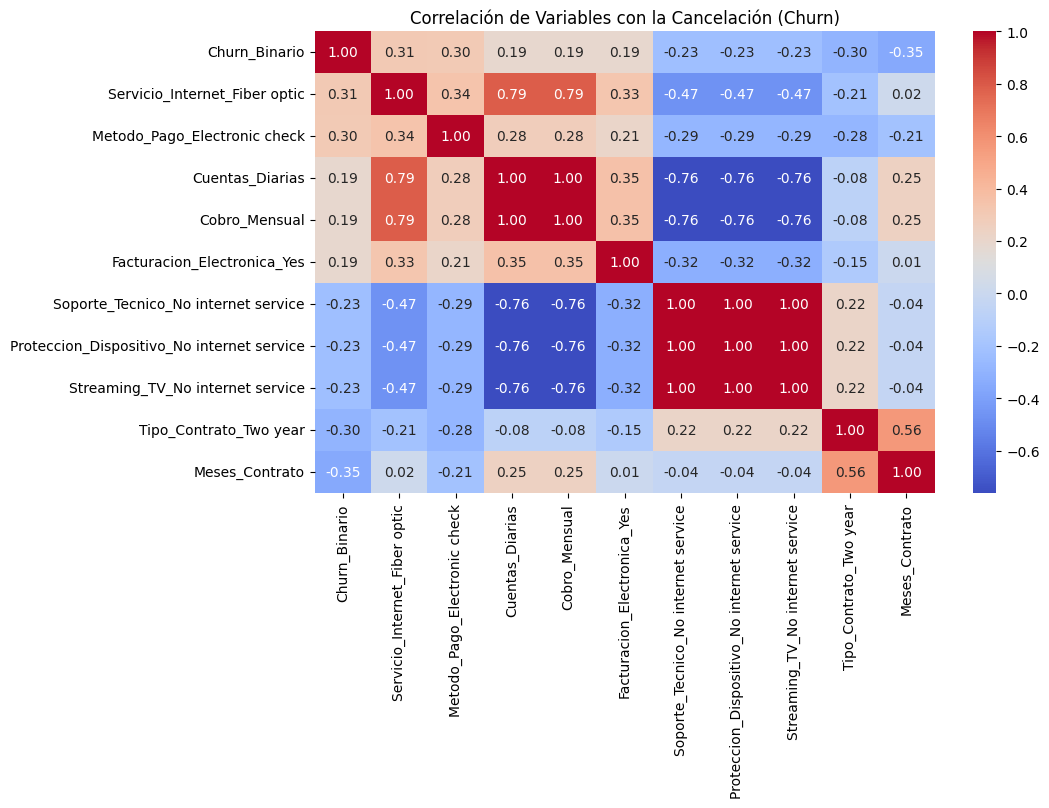

/tmp/ipykernel_147/2264649232.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_Binario', y='Meses_Contrato', data=df, ax=axes[0], palette='pastel')
/tmp/ipykernel_147/2264649232.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_Binario', y='Cobro_Total', data=df, ax=axes[1], palette='pastel')


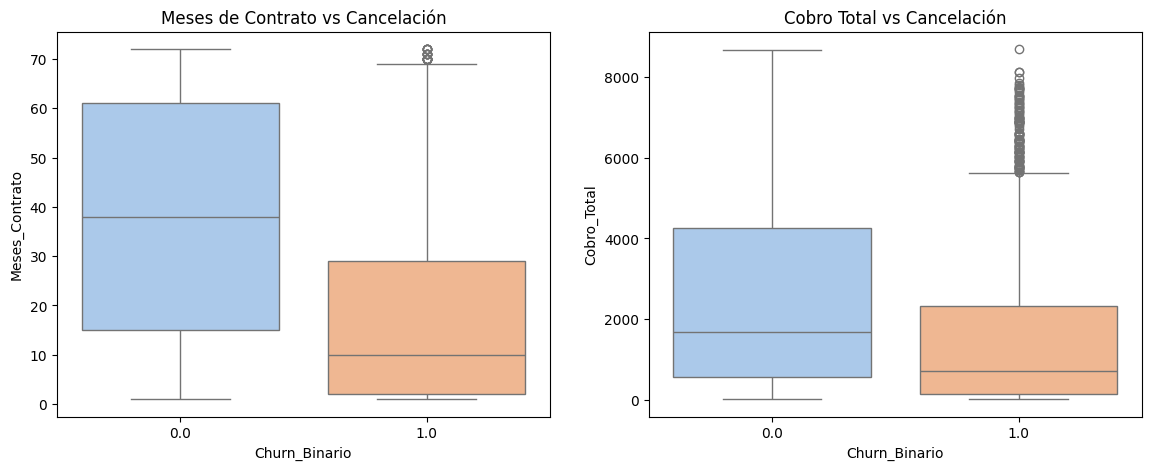

In [9]:
# Matriz de correlación enfocada en la variable objetivo
plt.figure(figsize=(10, 6))
df_corr = X_encoded.copy()
df_corr['Churn_Binario'] = y
correlaciones = df_corr.corr()['Churn_Binario'].sort_values(ascending=False)

# Tomamos las variables con mayor correlación (positiva y negativa)
top_features = correlaciones.head(6).index.tolist() + correlaciones.tail(5).index.tolist()
sns.heatmap(df_corr[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación de Variables con la Cancelación (Churn)')
plt.show()

# Gráficos dirigidos (Boxplots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='Churn_Binario', y='Meses_Contrato', data=df, ax=axes[0], palette='pastel')
axes[0].set_title('Meses de Contrato vs Cancelación')

sns.boxplot(x='Churn_Binario', y='Cobro_Total', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Cobro Total vs Cancelación')
plt.show()

Separación, Balanceo (SMOTE) y Normalización

In [12]:
# --------------------------------------------------------
# PARCHE DE SEGURIDAD: Eliminar valores nulos (NaN)
# --------------------------------------------------------
# 1. Conservamos solo las filas donde 'y' NO es nulo
mascara_no_nulos = y.notna()
X_encoded = X_encoded[mascara_no_nulos]
y = y[mascara_no_nulos]

# 2. Por seguridad, rellenamos cualquier nulo accidental en X con 0
# (o puedes usar X_encoded.dropna() si prefieres eliminar la fila entera)
X_encoded = X_encoded.fillna(0)

print(f"Borrados los valores nulos. Nuevas dimensiones de X: {X_encoded.shape}")
print(f"Nuevas dimensiones de y: {y.shape}")
print("-" * 50)

# --------------------------------------------------------
# AHORA SÍ: Separación, Balanceo (SMOTE) y Normalización
# --------------------------------------------------------
# 1. División Train/Test (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.30, random_state=42, stratify=y
)

# 2. Balanceo con SMOTE (Aplicado SOLO al conjunto de entrenamiento)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# 3. Normalización / Estandarización
scaler = StandardScaler()

# Lista de tus columnas estrictamente numéricas (las que no son 0 y 1)
cols_numericas = ['Meses_Contrato', 'Cobro_Mensual', 'Cobro_Total', 'Cuentas_Diarias', 'Cant_Servicios']

# Ajustamos el escalador con el entrenamiento y transformamos ambos
X_train_bal[cols_numericas] = scaler.fit_transform(X_train_bal[cols_numericas])
X_test[cols_numericas] = scaler.transform(X_test[cols_numericas])

print(f"Distribución de Churn en Entrenamiento después de SMOTE:\n{y_train_bal.value_counts()}")

Borrados los valores nulos. Nuevas dimensiones de X: (7032, 32)
Nuevas dimensiones de y: (7032,)
--------------------------------------------------
Distribución de Churn en Entrenamiento después de SMOTE:
Churn_Binario
1.0    3614
0.0    3614
Name: count, dtype: int64


Entrenamiento y Evaluación de Modelos


REPORTE DE RENDIMIENTO: REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

         0.0       0.86      0.86      0.86      1549
         1.0       0.61      0.61      0.61       561

    accuracy                           0.79      2110
   macro avg       0.73      0.74      0.74      2110
weighted avg       0.79      0.79      0.79      2110



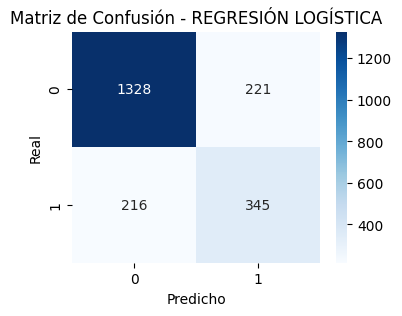


REPORTE DE RENDIMIENTO: RANDOM FOREST
              precision    recall  f1-score   support

         0.0       0.87      0.81      0.84      1549
         1.0       0.56      0.66      0.61       561

    accuracy                           0.77      2110
   macro avg       0.72      0.74      0.72      2110
weighted avg       0.79      0.77      0.78      2110



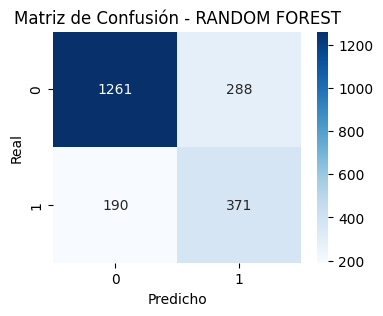

In [13]:
# --- ENTRENAMIENTO ---
# Modelo 1: Regresión Logística
modelo_lr = LogisticRegression(random_state=42, max_iter=1000)
modelo_lr.fit(X_train_bal, y_train_bal)
y_pred_lr = modelo_lr.predict(X_test)

# Modelo 2: Random Forest
modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
modelo_rf.fit(X_train_bal, y_train_bal)
y_pred_rf = modelo_rf.predict(X_test)

# --- EVALUACIÓN (Función auxiliar) ---
def reporte_modelo(nombre, y_verdadero, y_predicho):
    print(f"\n{'='*50}")
    print(f"REPORTE DE RENDIMIENTO: {nombre}")
    print(f"{'='*50}")
    print(classification_report(y_verdadero, y_predicho))

    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_verdadero, y_predicho), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()

reporte_modelo("REGRESIÓN LOGÍSTICA", y_test, y_pred_lr)
reporte_modelo("RANDOM FOREST", y_test, y_pred_rf)

Interpretación Estratégica

/tmp/ipykernel_147/1944082760.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancias.head(10), palette='viridis')


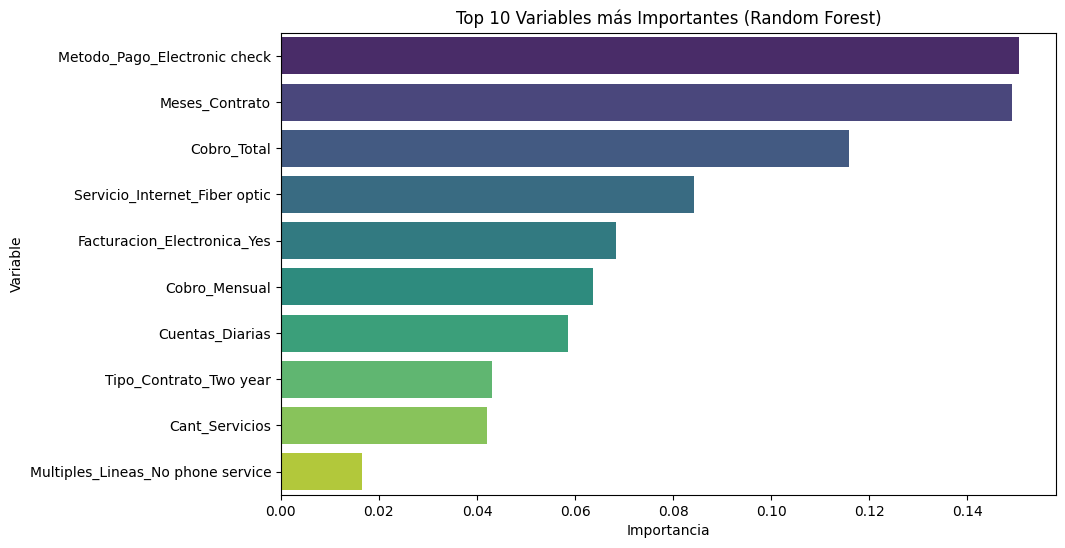


--- INSIGHTS ESTRATÉGICOS (REGRESIÓN LOGÍSTICA) ---

Factores que MÁS AUMENTAN la probabilidad de cancelar:
                      Variable  Coeficiente
23            Streaming_TV_Yes     3.699813
25     Streaming_Peliculas_Yes     3.635267
19  Proteccion_Dispositivo_Yes     3.404246
17         Respaldo_Online_Yes     3.239784
15        Seguridad_Online_Yes     3.106036

Factores que MÁS AYUDAN A RETENER al cliente:
                  Variable  Coeficiente
2            Cobro_Mensual    -0.307271
26  Tipo_Contrato_One year    -0.465822
27  Tipo_Contrato_Two year    -0.859255
1           Meses_Contrato    -2.066419
5           Cant_Servicios    -5.833276


In [14]:
# Importancia de Variables en Random Forest
importancias = pd.DataFrame({
    'Variable': X_train_bal.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importancias.head(10), palette='viridis')
plt.title('Top 10 Variables más Importantes (Random Forest)')
plt.show()

# Coeficientes de la Regresión Logística
coeficientes = pd.DataFrame({
    'Variable': X_train_bal.columns,
    'Coeficiente': modelo_lr.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

print("\n--- INSIGHTS ESTRATÉGICOS (REGRESIÓN LOGÍSTICA) ---")
print("\nFactores que MÁS AUMENTAN la probabilidad de cancelar:")
print(coeficientes.head(5))

print("\nFactores que MÁS AYUDAN A RETENER al cliente:")
print(coeficientes.tail(5))